In [1]:
import pandas as pd
import numpy as np

import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [2]:
# train.py

from src.data_loader import load_data

df = load_data(
    os.path.join(project_root, "data", "raw", "train.csv")
)

In [3]:
df = pd.read_csv("../nyc-taxi-trip-duration/train.zip", compression='zip')
df.head(10)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443
6,id1813257,1,2016-06-17 22:34:59,2016-06-17 22:40:40,4,-73.969017,40.757839,-73.957405,40.765896,N,341
7,id1324603,2,2016-05-21 07:54:58,2016-05-21 08:20:49,1,-73.969276,40.797779,-73.922470,40.760559,N,1551
8,id1301050,1,2016-05-27 23:12:23,2016-05-27 23:16:38,1,-73.999481,40.738400,-73.985786,40.732815,N,255
9,id0012891,2,2016-03-10 21:45:01,2016-03-10 22:05:26,1,-73.981049,40.744339,-73.973000,40.789989,N,1225


In [4]:
df.shape

(1458644, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [6]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [7]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [8]:
#Time Range
df['pickup_datetime'].min()

'2016-01-01 00:00:17'

In [9]:
df['pickup_datetime'].max()

'2016-06-30 23:59:39'

In [10]:
df.groupby(df['passenger_count'] == 0)['trip_duration'].mean()

passenger_count
False     959.461053
True     1718.433333
Name: trip_duration, dtype: float64

In [11]:
df.groupby(df['passenger_count'] == 0)['trip_duration'].median()

passenger_count
False    662.0
True      20.5
Name: trip_duration, dtype: float64

In [12]:
df['trip_duration'].quantile([0.90,0.95,0.99,0.999])

0.900     1634.000
0.950     2104.000
0.990     3440.000
0.999    85128.357
Name: trip_duration, dtype: float64

In [13]:
(df['trip_duration']>3440).sum()

np.int64(14575)

In [14]:
(df['trip_duration']>85128).sum()

np.int64(1459)

In [15]:
X = df.drop(columns=['trip_duration'])

In [16]:
type(X['pickup_datetime'])

pandas.core.series.Series

In [17]:
from src.feature_engineering import TimeFeatureTransformer

transformer = TimeFeatureTransformer()

In [18]:
import os

print(os.getcwd())

C:\Users\KAPIL\Jupyter_notebook\TensorFlow_Keras_Project\notebook


In [19]:
import importlib
import src.feature_engineering

importlib.reload(src.feature_engineering)

<module 'src.feature_engineering' from 'C:\\Users\\KAPIL\\Jupyter_notebook\\TensorFlow_Keras_Project\\src\\feature_engineering.py'>

In [20]:
import importlib
import src.feature_engineering

importlib.reload(src.feature_engineering)

from src.feature_engineering import TimeFeatureTransformer

In [21]:
transformer = TimeFeatureTransformer()
X_transformed = transformer.fit_transform(X.head())

In [22]:
X.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N


In [23]:
X.sample(1000)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
443449,id0387092,1,2016-05-23 12:08:15,2016-05-23 12:41:29,1,-73.989929,40.738995,-73.980698,40.767540,N
761153,id0826420,1,2016-06-23 21:58:57,2016-06-23 22:12:40,1,-73.977608,40.755520,-73.955139,40.807186,N
1348794,id1538738,1,2016-02-14 10:54:30,2016-02-14 11:00:51,1,-73.960358,40.797512,-73.945938,40.807983,N
267128,id3904209,1,2016-01-20 09:30:58,2016-01-20 09:43:06,1,-74.003044,40.739403,-74.005402,40.751148,N
1227244,id2599328,2,2016-05-07 01:02:28,2016-05-07 01:21:11,1,-73.873039,40.774181,-73.967690,40.754551,N
...,...,...,...,...,...,...,...,...,...,...
904834,id0149554,2,2016-01-16 17:51:39,2016-01-16 18:05:27,1,-73.994041,40.726768,-73.998550,40.740067,N
501105,id1054164,1,2016-04-10 19:14:39,2016-04-10 19:51:00,1,-73.990875,40.755829,-73.977554,40.675362,N
826855,id0645424,2,2016-01-08 14:52:38,2016-01-08 15:05:11,2,-73.955666,40.764400,-73.968941,40.766636,N
1206566,id0605613,2,2016-04-01 17:17:17,2016-04-01 17:23:39,1,-73.986450,40.726131,-73.985970,40.720669,N


In [24]:
transformer.fit_transform(
    X.sample(10000)
)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_hour,pickup_day,pickup_month,pickup_weekday,is_weekend,is_rush_hour,is_night,is_working_hour
628504,id3975679,2,2016-05-03 22:10:14,2016-05-03 22:23:29,2,-73.988495,40.737221,-73.995758,40.759235,N,22,Tuesday,5,1,0,0,0,0
1352127,id3819608,1,2016-05-01 19:44:01,2016-05-01 19:56:54,1,-73.978043,40.752056,-74.003647,40.733540,N,19,Sunday,5,6,1,1,0,0
370208,id2196320,1,2016-06-16 20:14:19,2016-06-16 20:44:28,3,-73.977913,40.757198,-73.829872,40.758781,N,20,Thursday,6,3,0,0,0,0
1336044,id1657746,2,2016-03-05 13:22:41,2016-03-05 13:26:25,5,-73.981216,40.779079,-73.968010,40.797337,N,13,Saturday,3,5,1,0,0,1
316625,id3014205,1,2016-04-06 17:29:44,2016-04-06 17:54:36,2,-73.870773,40.773788,-73.943207,40.800949,N,17,Wednesday,4,2,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183451,id1229224,1,2016-01-27 20:01:16,2016-01-27 20:14:52,2,-73.992027,40.750214,-74.007202,40.716133,N,20,Wednesday,1,2,0,0,0,0
201345,id2188831,2,2016-02-13 23:35:26,2016-02-13 23:51:14,6,-73.993019,40.742142,-74.013100,40.702351,N,23,Saturday,2,5,1,0,0,0
1266696,id0102112,1,2016-02-16 18:48:35,2016-02-16 18:54:30,1,-73.975883,40.750011,-73.970322,40.754169,N,18,Tuesday,2,1,0,1,0,1
66896,id3426416,1,2016-03-17 18:49:09,2016-03-17 18:52:41,1,-73.955254,40.779430,-73.948616,40.773903,N,18,Thursday,3,3,0,1,0,1


In [25]:
import importlib
import src.feature_engineering

importlib.reload(src.feature_engineering)

dir(src.feature_engineering)

['BaseEstimator',
 'DistanceTransformer',
 'LocationFeatureTransformer',
 'TimeFeatureTransformer',
 'TrafficFeatureTransformer',
 'TransformerMixin',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'np',
 'pd']

In [26]:
from src.feature_engineering import DistanceTransformer

distance_transformer = DistanceTransformer()

X_distance = (
    distance_transformer
    .fit_transform(X.head())
)


In [27]:
X_distance['distance_km'].describe()

count    5.000000
mean     2.472643
std      2.197984
min      1.188588
25%      1.485498
50%      1.498521
75%      1.805507
max      6.385098
Name: distance_km, dtype: float64

In [28]:
# from src.preprocessing import full_pipeline

# X_transformed = (
#     full_pipeline
#     .fit_transform(X.head())
# )

# X_transformed.columns

In [29]:
# type(full_pipeline)

In [30]:
full_pipeline = X

In [31]:
# from src.preprocessing import full_pipeline

# print(type(full_pipeline))

In [32]:
X_distance['distance_km'].describe()

count    5.000000
mean     2.472643
std      2.197984
min      1.188588
25%      1.485498
50%      1.498521
75%      1.805507
max      6.385098
Name: distance_km, dtype: float64

<Axes: >

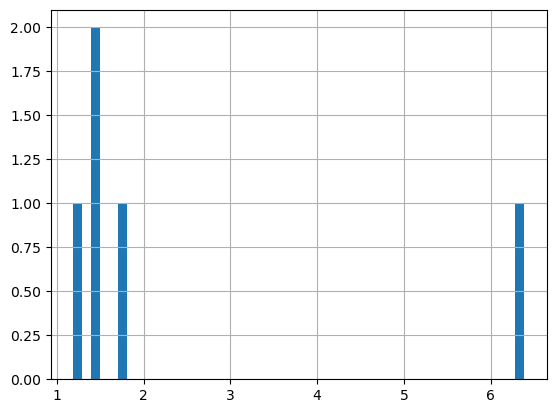

In [33]:
X_distance['distance_km'].hist(
    bins=50
)

In [34]:
X_distance.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,1.188588


<Axes: >

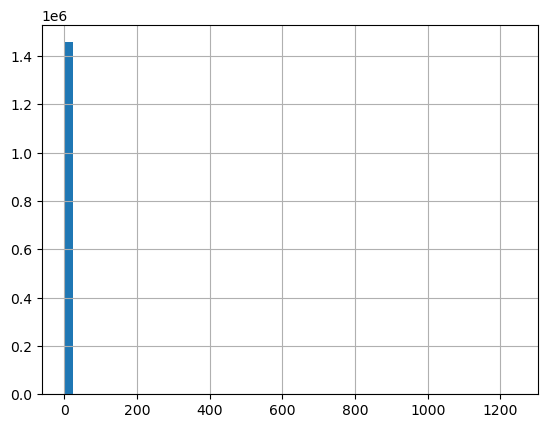

In [35]:
X_transformed = distance_transformer.fit_transform(X)

X_transformed['distance_km'].hist(
    bins=50
)

In [36]:
X_transformed['distance_km'].describe()

count    1.458644e+06
mean     3.440864e+00
std      4.296538e+00
min      0.000000e+00
25%      1.231837e+00
50%      2.093717e+00
75%      3.875337e+00
max      1.240909e+03
Name: distance_km, dtype: float64

In [37]:
numerical_columns = [
    'vendor_id',
    'passenger_count',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'pickup_hour',
    'pickup_month',
    'pickup_weekday',
    'distance_km'
]

categorical_columns = [
    'store_and_fwd_flag',
    'pickup_day'
]

In [38]:
# from src.preprocessing import feature_pipeline

# X_processed = feature_pipeline.fit_transform(X)

# print(type(X_processed))
# print(X_processed.shape)

In [39]:
# from sklearn.model_selection import train_test_split

# X_train_processed, X_test_processed = train_test_split(
# 	X_processed,
# 	test_size=0.2,
# 	random_state=42,
# 	shuffle=True
# )

# print(X_train_processed.shape)
# print(X_test_processed.shape)

In [40]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['trip_duration'])
y = df['trip_duration']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
print(y_train.shape)
print(y_test.shape)

(1166915,)
(291729,)


In [42]:
import src.feature_engineering

print(dir(src.feature_engineering))

['BaseEstimator', 'DistanceTransformer', 'LocationFeatureTransformer', 'TimeFeatureTransformer', 'TrafficFeatureTransformer', 'TransformerMixin', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'np', 'pd']


In [43]:
# from src.preprocessing import feature_pipeline

# X_sample = X.head(100)

# X_processed = feature_pipeline.fit_transform(X_sample)

# print(X_processed.shape)

In [44]:
from src.feature_engineering import (
    TimeFeatureTransformer,
    TrafficFeatureTransformer,
    DistanceTransformer,
    LocationFeatureTransformer
)

X_test = X.head(5)

X_test = TimeFeatureTransformer().fit_transform(X_test)

X_test = TrafficFeatureTransformer().fit_transform(X_test)

X_test = DistanceTransformer().fit_transform(X_test)

X_test = LocationFeatureTransformer().fit_transform(X_test)

print(X_test.columns.tolist())

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'is_weekend', 'is_rush_hour', 'is_night', 'is_working_hour', 'distance_km', 'lat_diff', 'lon_diff']


In [45]:
from src.feature_engineering import (LocationFeatureTransformer)

test = LocationFeatureTransformer().fit_transform(X.head())

print(test.columns.tolist())

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'lat_diff', 'lon_diff']


In [46]:
import src.feature_engineering

print(dir(src.feature_engineering))

['BaseEstimator', 'DistanceTransformer', 'LocationFeatureTransformer', 'TimeFeatureTransformer', 'TrafficFeatureTransformer', 'TransformerMixin', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'np', 'pd']


In [47]:
X_test = X.head()

X_test = TimeFeatureTransformer().fit_transform(X_test)

print(X_test.columns)

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday',
       'is_weekend', 'is_rush_hour', 'is_night', 'is_working_hour'],
      dtype='object')


In [48]:
X_test = X.head()

X_test = TimeFeatureTransformer().fit_transform(X_test)


print(X_test.columns.tolist())

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'is_weekend', 'is_rush_hour', 'is_night', 'is_working_hour']


In [49]:
print(numerical_columns)

['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_month', 'pickup_weekday', 'distance_km']


In [50]:
X_test = X.head(5)

X_test = TimeFeatureTransformer().fit_transform(X_test)

print(X_test.columns.tolist())

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'is_weekend', 'is_rush_hour', 'is_night', 'is_working_hour']


In [51]:
print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_month', 'pickup_weekday', 'distance_km']

Categorical Columns:
['store_and_fwd_flag', 'pickup_day']


In [52]:
from src.feature_engineering import LocationFeatureTransformer

X_test = X.head(5)

X_test = TimeFeatureTransformer().fit_transform(X_test)
X_test = DistanceTransformer().fit_transform(X_test)
sX_test = X.head(5)

X_test = TimeFeatureTransformer().fit_transform(X_test)
X_test = DistanceTransformer().fit_transform(X_test)
X_test = LocationFeatureTransformer().fit_transform(X_test)

print(X_test.columns.tolist())

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'is_weekend', 'is_rush_hour', 'is_night', 'is_working_hour', 'distance_km', 'lat_diff', 'lon_diff']


In [53]:
X_test = X.head(5)

X_test = TimeFeatureTransformer().fit_transform(X_test)
X_test = DistanceTransformer().fit_transform(X_test)
X_test = LocationFeatureTransformer().fit_transform(X_test)

print(sorted(X_test.columns.tolist()))

print("\n")

print(sorted(numerical_columns + categorical_columns))

['distance_km', 'dropoff_datetime', 'dropoff_latitude', 'dropoff_longitude', 'id', 'is_night', 'is_rush_hour', 'is_weekend', 'is_working_hour', 'lat_diff', 'lon_diff', 'passenger_count', 'pickup_datetime', 'pickup_day', 'pickup_hour', 'pickup_latitude', 'pickup_longitude', 'pickup_month', 'pickup_weekday', 'store_and_fwd_flag', 'vendor_id']


['distance_km', 'dropoff_latitude', 'dropoff_longitude', 'passenger_count', 'pickup_day', 'pickup_hour', 'pickup_latitude', 'pickup_longitude', 'pickup_month', 'pickup_weekday', 'store_and_fwd_flag', 'vendor_id']


In [54]:
import importlib
import src.preprocessing

importlib.reload(src.preprocessing)

<module 'src.preprocessing' from 'C:\\Users\\KAPIL\\Jupyter_notebook\\TensorFlow_Keras_Project\\src\\preprocessing.py'>

In [55]:
import importlib
import src.preprocessing

importlib.reload(src.preprocessing)

<module 'src.preprocessing' from 'C:\\Users\\KAPIL\\Jupyter_notebook\\TensorFlow_Keras_Project\\src\\preprocessing.py'>

In [ ]:
print(X.columns)